In [60]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field 
import operator


In [61]:
load_dotenv()

True

In [62]:
model = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')


In [63]:
# we want essay feedback and a score from 1-10 

# simple prompt can give but it will be provide in correct format 7 out of 10 times. 
# WE have to make the output reliable and in correct format. For that we will use Structured Output model.



In [64]:
class EvaluationSchema(BaseModel):

    # This is a pydantic model. It will have feedback and score
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10", ge=0,le=10)

In [65]:
structured_model = model.with_structured_output(EvaluationSchema) # this structured model will reliable output based on the schema defined.


In [66]:
essay = """
        # The Role of India in Artificial Intelligence

## Introduction

Artificial Intelligence (AI) has emerged as one of the most transformative technologies of the twenty-first century. It is changing the way people work, communicate, learn, conduct business and interact with governments. From generative AI and robotics to healthcare diagnostics, agriculture, financial technology and intelligent transportation, AI is becoming an important foundation of modern economic and social development.

In this rapidly changing technological landscape, India is assuming an increasingly important role. India is not merely a large consumer of AI technologies; it is becoming an important centre for AI talent, research, software development, entrepreneurship, digital infrastructure and AI-enabled public services. The country's large population, expanding digital economy, strong information-technology sector, growing startup ecosystem and diverse linguistic and social environment provide it with unique advantages.

The Government of India has also recognized AI as a strategic technology. The IndiaAI Mission, approved in 2024 with an outlay of ₹10,371.92 crore, seeks to develop computing infrastructure, indigenous AI capabilities, datasets, skills, startups and responsible AI systems. By 2026, the government reported that more than 38,000 GPUs had been onboarded for a common AI computing facility, demonstrating an effort to make advanced computing more accessible to Indian researchers and startups.

India's role in AI, therefore, extends beyond technological development. It involves economic growth, employment, education, healthcare, governance, national security, international cooperation and the development of AI systems that can address the needs of the Global South.

## 1. India as a Global AI Talent Hub

One of India's greatest strengths in AI is its human capital. For decades, India has developed a large pool of engineers, software developers, scientists, mathematicians and technology professionals. This foundation has allowed the country to participate actively in the global AI revolution.

According to the Government of India's summary of the Stanford Global AI Index 2025, India ranked third globally in AI competitiveness and ecosystem vibrancy. India was also reported to be the second-largest contributor to AI projects on GitHub. Another government backgrounder citing the Stanford AI Index reported that India's AI-skilled workforce had a relative skill penetration 2.5 times the global average across comparable occupations.

This talent base is important because AI requires expertise in computer science, statistics, mathematics, data science, machine learning, natural-language processing, robotics and domain-specific knowledge. Indian professionals are already contributing to AI research and development in universities, startups, multinational technology companies and global capability centres.

India's large English-speaking technical workforce has also made it an attractive location for global technology companies. Increasingly, however, India's AI opportunity is moving beyond traditional outsourcing. Indian engineers and entrepreneurs are working on AI products, foundation models, cybersecurity systems, healthcare technologies, enterprise software and applications designed for Indian languages and markets.

The challenge is to ensure that India's talent advantage is accompanied by high-quality research, advanced infrastructure and opportunities for innovation within the country itself.

## 2. The IndiaAI Mission

A major pillar of India's AI strategy is the IndiaAI Mission. The mission was approved by the Union Cabinet in March 2024 with a budget of ₹10,371.92 crore. Its objective is to establish a comprehensive AI ecosystem through public-private partnerships and investment in computing, data, skills, startups, research and responsible AI.

The mission contains several important components:

* **AI computing capacity:** expanding access to high-performance computing and GPUs.
* **IndiaAI Innovation Centre:** supporting indigenous foundation and multimodal AI models.
* **AI datasets:** improving access to high-quality non-personal datasets.
* **Application development:** encouraging AI applications with social and economic impact.
* **FutureSkills:** expanding AI education and training.
* **Startup financing:** supporting AI and deep-tech entrepreneurs.
* **Safe and Trusted AI:** developing tools and frameworks for responsible AI.

The importance of this approach is that AI development requires much more than software. It needs computing power, data, researchers, entrepreneurs, capital, education, infrastructure and effective governance. India's policy is therefore increasingly focused on developing an entire ecosystem rather than depending exclusively on foreign AI platforms.

## 3. India and Indigenous AI Models

The global AI race has largely been dominated by companies and research institutions in the United States and China. India faces the challenge of developing competitive AI capabilities while avoiding excessive dependence on foreign technologies.

One important area is the development of indigenous foundation models. India's diversity makes this particularly significant. The country has hundreds of languages and dialects and an enormous variety of cultural, economic and social contexts. AI models developed primarily using English-language or Western datasets may not perform equally well for Indian users.

Indigenous models can potentially improve AI systems for Indian languages, speech recognition, translation, education, agriculture, healthcare and government services.

The IndiaAI Mission explicitly supports the development of indigenous large multimodal and domain-specific foundational models. The government's AI strategy also emphasizes language technologies and the integration of AI with India's digital public infrastructure.

India therefore has an opportunity to develop not simply an Indian version of an existing AI model, but AI systems designed for multilingual and diverse populations.

## 4. India's Digital Public Infrastructure and AI

Perhaps India's most distinctive contribution to the global AI ecosystem may come from the combination of AI with Digital Public Infrastructure (DPI).

Over the past decade, India has built large-scale digital systems for identity, payments, document services and public delivery. Systems such as Aadhaar, Unified Payments Interface (UPI), DigiLocker and other digital platforms have demonstrated India's ability to deploy technology at population scale.

This infrastructure can provide a foundation for AI applications. AI can help governments analyse information, improve service delivery, identify patterns, automate routine processes and provide citizens with more accessible interfaces.

The combination of DPI and AI could become particularly important for developing countries. Instead of building expensive, isolated technological systems, countries could potentially adopt interoperable digital infrastructure and then add AI-based services.

The World Economic Forum has highlighted India's ecosystem approach, including AI-ready datasets, multilingual resources, AI sandboxes and partnerships for applications in healthcare, finance and public services.

This gives India an opportunity to demonstrate a model of **AI for public good**, rather than focusing only on commercial applications.

## 5. AI in Healthcare

Healthcare is one of the areas where AI could have a major impact in India.

India has a huge population and significant differences in access to healthcare between metropolitan areas, smaller towns and rural communities. There are also shortages of medical specialists in many areas. AI can help bridge some of these gaps.

Potential applications include:

* medical-image analysis;
* early detection of diseases;
* clinical decision support;
* drug discovery;
* remote healthcare;
* personalised treatment;
* hospital management;
* patient monitoring;
* medical transcription and documentation; and
* health education.

AI-powered diagnostic tools could assist doctors by identifying patterns in X-rays, CT scans, MRI images and other medical data. In rural areas, AI-enabled telemedicine could help connect patients with healthcare professionals.

However, AI should complement rather than blindly replace medical professionals. Healthcare AI must be tested rigorously because incorrect recommendations can have serious consequences. Privacy, informed consent, data security and accountability are equally important.

India's contribution can be especially valuable in developing affordable healthcare AI designed for large and diverse populations.

## 6. AI in Agriculture

Agriculture is another sector in which AI can make a substantial difference.

Indian farmers face problems such as unpredictable weather, pests, diseases, water shortages, fluctuating prices and limited access to agricultural expertise. AI can analyse satellite imagery, weather data, soil conditions and crop information to provide farmers with useful predictions and recommendations.

Possible applications include:

* crop disease detection;
* precision irrigation;
* weather forecasting;
* yield prediction;
* soil analysis;
* pest identification;
* supply-chain optimisation; and
* agricultural market intelligence.

Smartphone-based AI assistants could also provide information in regional languages, making agricultural knowledge more accessible.

The significance of this development goes beyond productivity. If AI can be made affordable and accessible to small farmers, it could contribute to rural development and reduce inequalities in access to technology.

## 7. AI in Education

Education is another field where India's large population makes AI particularly relevant.

AI can support personalised learning by analysing the strengths and weaknesses of individual students. Intelligent tutoring systems can provide explanations, exercises and feedback according to a student's learning level.

AI can also assist teachers by generating educational materials, translating content, evaluating certain forms of student work and identifying students who may need additional support.

India's linguistic diversity creates another important opportunity. AI-based translation and speech technologies could make educational resources available in more Indian languages.

At the same time, AI raises concerns about academic integrity, excessive dependence on automated systems and unequal access to technology. Schools and universities therefore need to teach students not merely how to use AI but how to evaluate AI-generated information critically.

## 8. AI and India's Economy

AI has the potential to become a major driver of India's economic growth.

India's IT and business-services industries have traditionally depended heavily on software services and outsourcing. AI is now changing this model. Companies can move from providing labour-intensive services toward higher-value activities such as AI engineering, product development, data analytics, automation and intelligent enterprise solutions.

Investment in Indian AI startups is also growing. A 2026 Venture Intelligence report found that Indian AI companies attracted about $1.2 billion across 188 investments during 2025, with AI accounting for about 12% of India's venture-capital funding.

This growth can create opportunities in areas such as:

* AI software;
* robotics;
* cybersecurity;
* financial technology;
* healthcare technology;
* industrial automation;
* climate technology;
* language technology;
* enterprise AI; and
* deep technology.

The challenge is to turn India's large pool of technical talent into globally competitive intellectual property and products.

## 9. AI and Employment

AI presents both opportunities and risks for India's workforce.

On one hand, AI can create new occupations in machine learning, data science, AI engineering, robotics, cybersecurity, AI safety and technology management. It can also increase productivity and enable workers to perform tasks that previously required large teams.

On the other hand, automation may reduce demand for certain repetitive jobs. This is especially significant for India's IT and business-process industries, which employ millions of people.

Recent reporting has highlighted concerns that generative AI is disrupting India's traditional IT employment model. This does not necessarily mean that AI will simply eliminate jobs. More often, occupations are likely to change, with some tasks automated and new responsibilities emerging.

India therefore needs a major programme of reskilling and upskilling. Workers must learn to collaborate with AI rather than compete with it on tasks that machines can perform more efficiently.

Education and vocational training will be central to this transition.

## 10. AI Startups and Entrepreneurship

India's startup ecosystem provides another important foundation for AI development.

Young Indian companies are developing solutions in areas ranging from financial services and healthcare to logistics, education, cybersecurity and language technologies.

The IndiaAI Mission's startup-financing component recognizes that promising AI companies often require substantial capital before they become commercially successful.

Government support can be especially important in deep-tech AI because research and computing costs can be high and the time required to reach commercialisation can be longer than in conventional software startups.

India must therefore encourage an environment in which entrepreneurs can experiment, fail, learn and build globally competitive companies.

## 11. AI and Semiconductors

Artificial intelligence depends heavily on computing hardware. Advanced GPUs and other specialised processors are essential for training and operating modern AI systems.

This makes semiconductor manufacturing strategically important to India's AI ambitions.

India has historically depended heavily on imported semiconductor components. Developing domestic chip design and manufacturing capabilities can strengthen India's technological sovereignty and make its AI ecosystem more resilient.

Government policy is increasingly connecting AI with semiconductor development. In June 2026, the government reported that ₹1.64 lakh crore of investment had been approved across 12 semiconductor projects, while India's AI computing infrastructure had expanded to more than 45,000 GPUs.

India's long-term objective should not simply be to assemble electronic products. It should develop capabilities across semiconductor design, manufacturing, packaging, specialised AI chips, data centres and computing infrastructure.

## 12. AI Governance and Responsible AI

Technological progress without responsible governance can create serious risks.

AI systems can produce inaccurate information, reinforce bias, violate privacy, enable fraud or misinformation, and make decisions that are difficult to explain. As AI becomes more powerful, questions of accountability and safety become increasingly important.

India has been developing a governance approach that seeks to balance innovation with safety. The Office of the Principal Scientific Adviser reports that India's November 2025 AI governance guidelines promote a risk-based, relatively light-touch approach while emphasizing transparency, fairness, safety, accountability and public participation.

This is important because excessive regulation can discourage innovation, while inadequate regulation can allow harmful technologies to spread without safeguards.

India's challenge is to create rules that protect citizens while allowing researchers and entrepreneurs to experiment.

## 13. India's Role in Global AI Governance

India's importance in AI extends beyond its borders.

As one of the world's largest economies and most populous countries, India has a significant voice in international discussions about AI governance. It can represent the concerns of developing countries that may not have the financial resources to compete directly with the world's largest technology companies.

India can advocate for:

* affordable access to AI computing;
* open and interoperable technologies;
* responsible AI;
* multilingual AI;
* digital inclusion;
* protection of developing countries' interests;
* international cooperation on AI safety; and
* AI applications for sustainable development.

The AI Impact Summit held in India in 2026 further reflected India's ambition to position itself as an important participant in the global AI conversation. India's approach increasingly emphasizes the idea that AI should benefit people, society and the wider world rather than only a small group of technology companies or countries.

## 14. India's Opportunity in the Global South

India's development experience may be particularly relevant to countries in Asia, Africa and other parts of the Global South.

Many developing countries face similar problems: limited healthcare infrastructure, shortages of skilled professionals, linguistic diversity, agricultural challenges and constrained government resources.

India can potentially export AI-enabled solutions designed around these conditions.

For example, low-cost AI healthcare tools, multilingual education systems, agricultural advisory platforms and digital governance technologies could be adapted for other developing economies.

India's experience with scalable digital public infrastructure gives it an additional advantage. Rather than simply becoming a market for foreign AI products, India can become a provider of technology and institutional models for other developing nations.

## 15. Major Challenges Facing India

Despite its considerable strengths, India faces serious challenges in becoming a global AI leader.

### First, computing infrastructure

Training advanced AI models requires enormous computing resources. Although India's GPU capacity is growing rapidly, it still needs much greater access to advanced processors, data centres and affordable electricity.

### Second, research capability

India has a strong software workforce but needs greater investment in fundamental AI research. World-class research universities and laboratories are essential for long-term technological independence.

### Third, talent shortages

The number of AI professionals is growing, but demand is growing rapidly as well. Recent reporting has highlighted a significant AI talent gap in India.

### Fourth, data quality

AI systems depend on high-quality data. India needs reliable, representative and legally usable datasets while protecting personal privacy.

### Fifth, unequal access

AI could widen inequality if advanced tools remain concentrated in large corporations and wealthy urban centres. Rural communities, small businesses and disadvantaged groups must also benefit.

### Sixth, employment disruption

Workers in repetitive and routine occupations may face significant changes. Reskilling therefore needs to become a continuous part of India's economic policy.

### Seventh, dependence on foreign hardware

India's AI ambitions will remain vulnerable if it depends heavily on imported advanced processors and other critical components.

### Eighth, ethical and security risks

Deepfakes, misinformation, cyberattacks, algorithmic bias and misuse of AI present major challenges. India's AI development must therefore be accompanied by strong security and ethical safeguards.

## 16. The Future of India's AI Journey

India's future role in AI will depend on whether it can combine its existing strengths with sustained investment in research and infrastructure.

The country already possesses several major advantages: a large technical workforce, a huge digital population, an expanding startup ecosystem, digital public infrastructure, a large domestic market and a government increasingly focused on AI.

The next stage should focus on moving from **AI adoption to AI creation**.

India should aim to build globally competitive AI models, research institutions, semiconductor capabilities, AI products and intellectual property. At the same time, it should ensure that AI remains accessible to ordinary citizens.

India should also develop AI applications in areas where its social and economic needs are greatest. Healthcare, agriculture, education, climate resilience, financial inclusion and public administration offer opportunities to demonstrate how AI can solve real-world problems.

## Conclusion

India's role in artificial intelligence is becoming increasingly significant. The country is simultaneously a major source of AI talent, a rapidly growing market for AI, an emerging centre for AI startups and research, a developer of digital public infrastructure and an increasingly active participant in global AI governance.

The IndiaAI Mission represents an important step toward building domestic AI capabilities, while the country's digital infrastructure provides a foundation upon which AI applications can be deployed at enormous scale. Government data indicates that India has already achieved a strong position in global AI competitiveness, talent and developer participation.

However, India's success should not be measured only by the number of AI models it develops or the amount of investment it attracts. The more important question is whether AI can improve the lives of India's citizens.

India has the opportunity to develop a distinctive model of artificial intelligence—one that combines technological ambition with affordability, inclusion, multilingualism, digital public infrastructure and social responsibility. If it succeeds, India could become not merely a participant in the global AI revolution but one of the countries that helps define its future.

The ultimate role of India in AI, therefore, is not simply to **make AI in India**, but to **make AI work for India and for the wider world**.

"""

In [67]:
bad_essay = """# Artificial Intelligence in India

Artificial Intelligence, or AI, is becoming very important in India nowadays. It is a technology which can do many things that normally humans do. For example, AI can help in education, hospitals, banking, agriculture and many other sectors. India is a large country and because of its population and technology development, AI can be very useful here.

In education, AI can help students to learn things according to their level. It can also help teachers in checking assignments and giving suggestions. In healthcare, AI can help doctors by finding diseases from medical reports and images. But AI cannot completely replace doctors because human judgement is still important.

India is also using AI in agriculture. Farmers can use AI to know about weather, crops and soil conditions. This can help them make better decisions. Companies in India are also using AI for customer service, fraud detection and other business activities. Many Indian IT companies are investing in AI because they know it will become more important in future.

However, there are also some problems with AI. One major problem is that some jobs can be affected because machines can do repetitive work. There are also concerns about privacy and wrong information given by AI. India needs proper rules so that AI is used in a safe and useful manner.

In conclusion, AI has a lot of potential in India. It can improve many sectors and make work faster and easier. At the same time, India should not depend on AI too much and should focus on using it responsibly. If used properly, AI can help India develop more in the future.


"""


In [68]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {bad_essay}"
structured_model.invoke(prompt)

EvaluationSchema(feedback='The essay is well-structured, clear, and easy to follow. It provides a balanced view of Artificial Intelligence in India, covering both its benefits across various sectors like education, healthcare, and agriculture, and its challenges such as job displacement and privacy concerns. The grammar and vocabulary are generally good and appropriate for an intermediate level, though some sentences are a bit simple and could be connected with more advanced transitional phrases. Overall, it is a coherent and informative piece of writing.', score=8)

In [69]:
result = structured_model.invoke(prompt)

In [70]:
result.score

8

In [71]:
result.feedback

"The essay is well-structured, clear, and easy to understand. It covers various aspects of AI in India, including its applications in education, healthcare, agriculture, and business, as well as the associated challenges. The vocabulary is appropriate and accessible, though somewhat basic in places (e.g., repeating words like 'help', 'things', and 'good'). Grammatically, the sentences are generally correct with proper punctuation and flow. To improve further, the writer could use more advanced transitional phrases and richer vocabulary to enhance the academic tone."

In [72]:
class UPSCState(TypedDict):
    essay: str 
    language_feedback: str 
    analysis_feedback: str 
    clarity_feedback: str 
    overall_feedback: str 
    individual_scores: Annotated[list[int] , operator.add] # removes the possiblity of override using the reducer function- Add
    avg_score: float 

In [73]:
def evaluate_language(state: UPSCState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [74]:
def evaluate_analysis(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [75]:
def evaluate_thought(state: UPSCState):
    
    prompt = f'Evaluate the clarity of though of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [76]:
def final_evaluation(state: UPSCState):

    # summary feedback 
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state['analysis_feedback']} \n depth of analysis feedback - {state['analysis_feedback']} \n clarity of thought feedback - {state['clarity_feedback']}'

    overall_feedback = model.invoke(prompt).content[0]['text'] # Notice here we are using the normal model here not the structured_model... we just want the feedback here. 

    # average calculate 
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])


    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

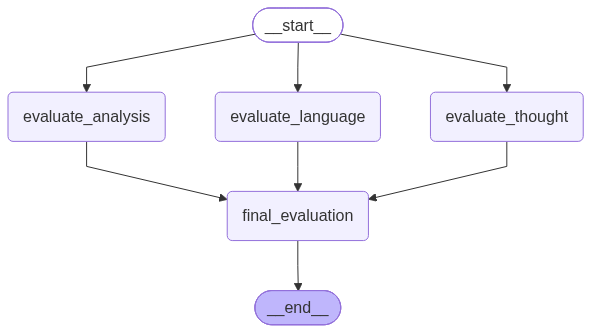

In [77]:
graph = StateGraph(UPSCState)

graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("final_evaluation", final_evaluation)

# edges 
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

graph.compile()

In [78]:
workflow = graph.compile()

In [ ]:
initial_state = {
    'essay': bad_essay,     
}

workflow.invoke(initial_state) # type: ignore



{'essay': '# Artificial Intelligence in India\n\nArtificial Intelligence, or AI, is becoming very important in India nowadays. It is a technology which can do many things that normally humans do. For example, AI can help in education, hospitals, banking, agriculture and many other sectors. India is a large country and because of its population and technology development, AI can be very useful here.\n\nIn education, AI can help students to learn things according to their level. It can also help teachers in checking assignments and giving suggestions. In healthcare, AI can help doctors by finding diseases from medical reports and images. But AI cannot completely replace doctors because human judgement is still important.\n\nIndia is also using AI in agriculture. Farmers can use AI to know about weather, crops and soil conditions. This can help them make better decisions. Companies in India are also using AI for customer service, fraud detection and other business activities. Many Indian 